# 00 — Synthetic DGP Exploration

Mirrors `04_synthetic_data_generation.ipynb` (original).
Explores the synthetic DGP structure, sub-group distributions, and the
heterogeneity sweep.  No outputs are saved — this is a reference notebook only.

Run this once to understand the DGP before running the experiment.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
REVISED_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [PROJECT_ROOT, REVISED_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from cdv_utils.synthetic_dgp import (
    generate_synthetic_dataset, get_w_cols,
    SUBGROUP_FEATURES, DEFAULT_VARIANT_SHARES,
    SG0_STRUCTURAL_SUBGROUPS, MISSING_VALUE
)
from cdv_utils.analysis_utils import create_synthetic_variant_elbow_chart

print('Libraries loaded.')

Libraries loaded.


## 1. Generate Sample Dataset

In [2]:
df = generate_synthetic_dataset(n=10_000, alpha=0.5, seed=42)
w_cols = get_w_cols()
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Feature columns: {w_cols}')

Shape: (10000, 13)
Columns: ['X1', 'X2', 'V', 'E', 'Z1', 'Z2', 't', 'y', 'y0', 'y1', 'ite', 'subgroup', 'structural_subgroup']
Feature columns: ['X1', 'X2', 'V', 'E', 'Z1', 'Z2']


## 2. Sub-group Distribution

In [3]:
sg_counts = df['subgroup'].value_counts().sort_index()
for sg in range(6):
    features = SUBGROUP_FEATURES[sg]
    print(f'SG{sg}: n={sg_counts.get(sg,0):4d} ({sg_counts.get(sg,0)/len(df)*100:5.1f}%) | {features}')

print(f'\nTop-3 coverage: {sg_counts.iloc[:3].sum()/len(df)*100:.1f}%')

SG0: n=4034 ( 40.3%) | ['X1', 'X2', 'V', 'Z1']
SG1: n=3024 ( 30.2%) | ['X1', 'X2', 'E', 'V']
SG2: n=1675 ( 16.8%) | ['X1', 'X2', 'V', 'E', 'Z2']
SG3: n= 482 (  4.8%) | ['X1', 'X2', 'Z1', 'Z2']
SG4: n= 386 (  3.9%) | ['X1', 'X2', 'E', 'Z1']
SG5: n= 399 (  4.0%) | ['X1', 'X2', 'V', 'Z1', 'Z2']

Top-3 coverage: 87.3%


## 3. Elbow Chart

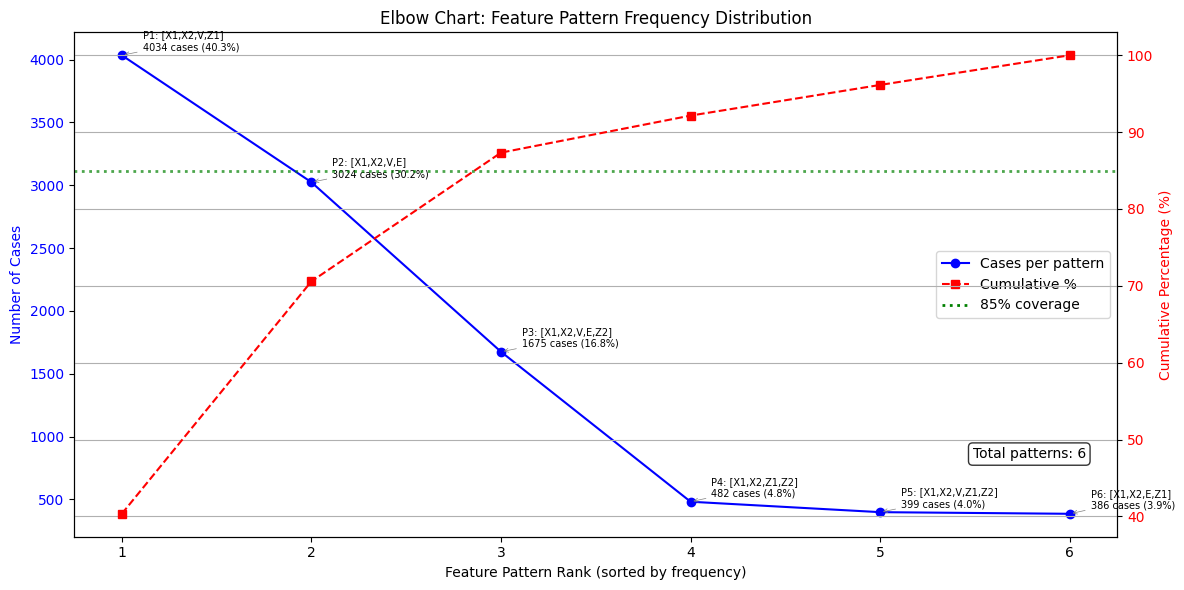


Total unique feature patterns: 6
Total cases: 10000

Top patterns coverage:
  Pattern 1 (111010): features=['X1', 'X2', 'V', 'Z1'], n=4034 (40.3%), cumulative=40.3%
  Pattern 2 (111100): features=['X1', 'X2', 'V', 'E'], n=3024 (30.2%), cumulative=70.6%
  Pattern 3 (111101): features=['X1', 'X2', 'V', 'E', 'Z2'], n=1675 (16.8%), cumulative=87.3%
  Pattern 4 (110011): features=['X1', 'X2', 'Z1', 'Z2'], n=482 (4.8%), cumulative=92.2%
  Pattern 5 (111011): features=['X1', 'X2', 'V', 'Z1', 'Z2'], n=399 (4.0%), cumulative=96.1%
  Pattern 6 (110110): features=['X1', 'X2', 'E', 'Z1'], n=386 (3.9%), cumulative=100.0%


In [4]:
sorted_patterns, counts, cumulative_pct, total = create_synthetic_variant_elbow_chart(df, w_cols)
plt.show()

## 4. Heterogeneity Sweep

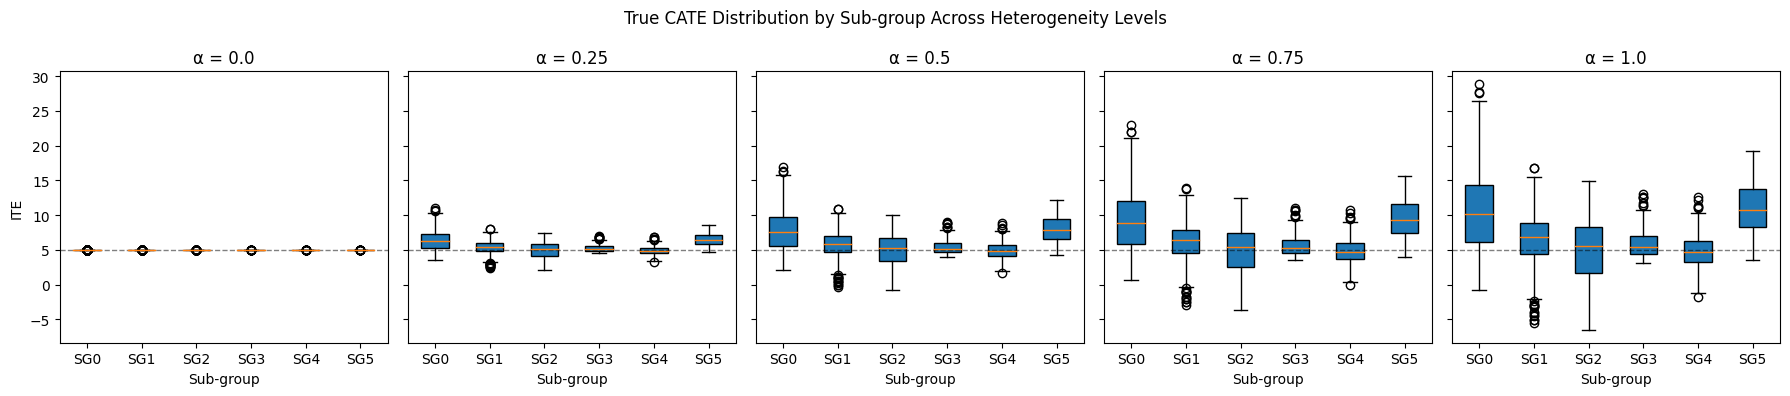

ITE mean by sub-group:


,α=0.0,α=0.25,α=0.5,α=0.75,α=1.0
SG0,5.0,6.36,7.73,9.09,10.45
SG1,5.0,5.42,5.83,6.25,6.67
SG2,5.0,5.01,5.02,5.04,5.05
SG3,5.0,5.22,5.44,5.66,5.88
SG4,5.0,4.95,4.90,4.85,4.80
SG5,5.0,6.50,8.01,9.51,11.02


In [5]:
ALPHA_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(ALPHA_VALUES), figsize=(18, 4), sharey=True)

for idx, alpha in enumerate(ALPHA_VALUES):
    df_a = generate_synthetic_dataset(n=5000, alpha=alpha, seed=42)
    data_to_plot = [df_a[df_a['subgroup'] == sg]['ite'].values for sg in range(6)]
    bp = axes[idx].boxplot(data_to_plot, labels=[f'SG{i}' for i in range(6)], patch_artist=True)
    axes[idx].axhline(y=5, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].set_title(f'α = {alpha}')
    axes[idx].set_xlabel('Sub-group')
    if idx == 0:
        axes[idx].set_ylabel('ITE')

plt.suptitle('True CATE Distribution by Sub-group Across Heterogeneity Levels', fontsize=12)
plt.tight_layout()
plt.show()

summary = pd.DataFrame(index=[f'SG{i}' for i in range(6)])
for alpha in ALPHA_VALUES:
    df_a = generate_synthetic_dataset(n=5000, alpha=alpha, seed=42)
    summary[f'α={alpha}'] = [df_a[df_a['subgroup'] == sg]['ite'].mean() for sg in range(6)]
print('ITE mean by sub-group:')
display(summary.round(2))